# Escalado
Conjunto de datos: iris (incluido en sklearn)
Este conjunto de datos es compacto y perfecto para demostrar técnicas de escalado.

In [16]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
iris = load_iris(as_frame=True)
data = iris.data

In [3]:
# Visualizar las estadísticas iniciales
print("Estadísticas iniciales:")
data.describe()

Estadísticas iniciales:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
data_minmax = pd.DataFrame(minmax_scaler.fit_transform(data), columns=data.columns)

In [5]:
# Aplicar StandardScaler
standard_scaler = StandardScaler()
data_standard = pd.DataFrame(standard_scaler.fit_transform(data), columns=data.columns)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre las estadísticas originales y las del escalado MinMax?


================= Estadisticas iniciales =================
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

================= Estadisticas con escalado MinMax =================
       sepal length (cm)  sepal width (cm)  petal l

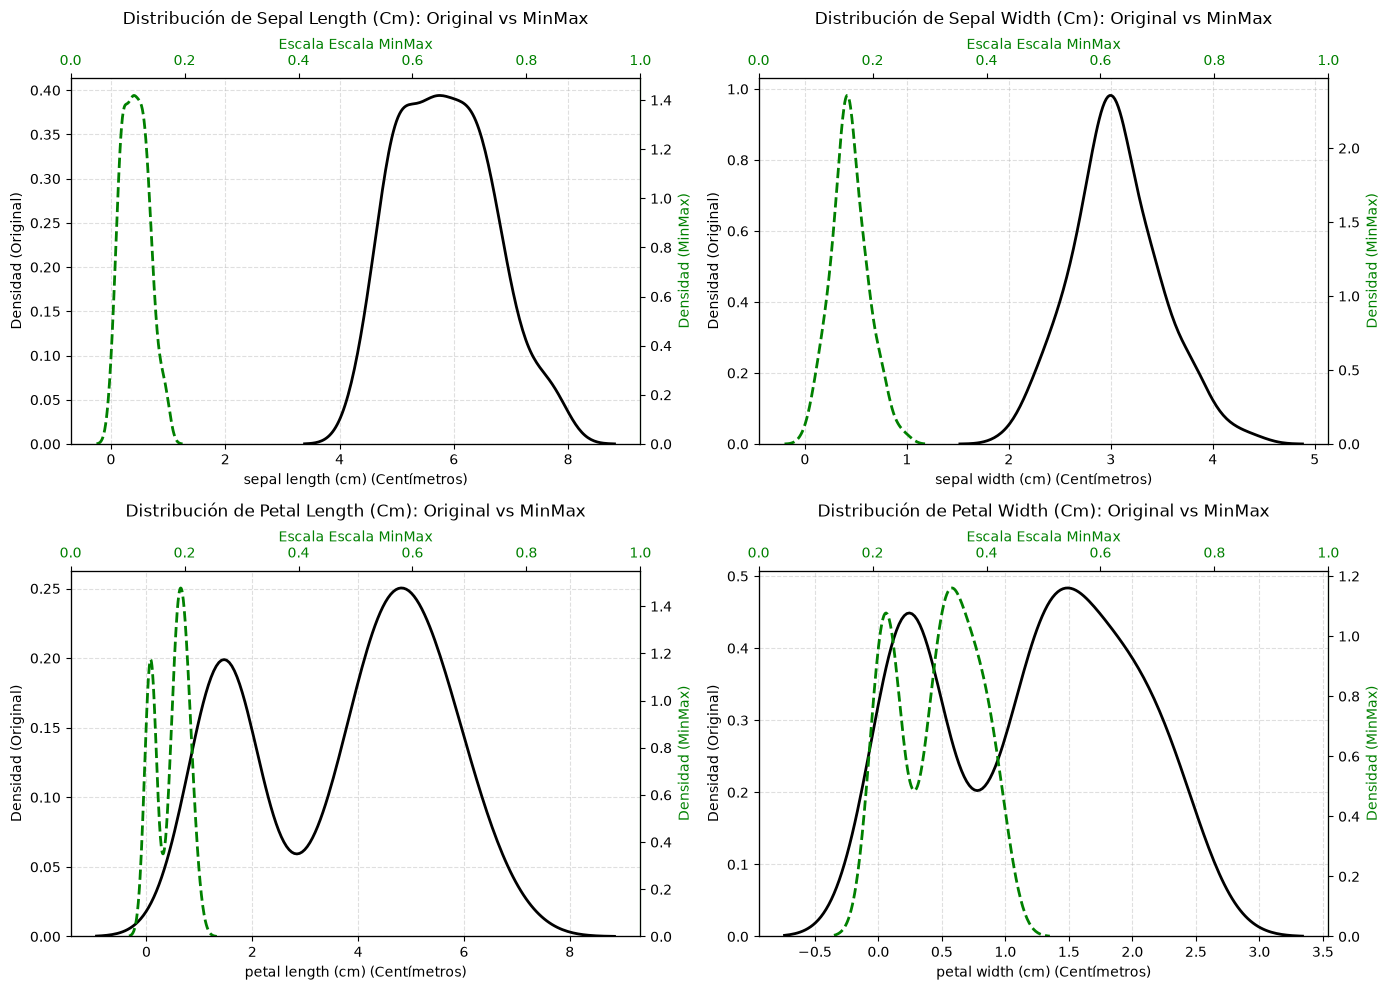

In [ ]:
# Definir las variables a graficar
variables = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# Configurar la cuadrícula de 2x2 para los 4 subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()  # Convertir la matriz de 2x2 en una lista para iterar

# 3. Iterar sobre cada variable del dataset Iris
for i, col in enumerate(variables):
    ax1 = axes[i]
    
    # --- Graficar la versión ORIGINAL ---
    sns.kdeplot(data[col], ax=ax1, color='black', linewidth=2, label='Original')
    ax1.set_title(f'Distribución de {col.replace("_", " ").title()}: Original vs MinMax', fontsize=12, pad=10)
    ax1.set_xlabel(f'{col} (Centímetros)', color='black')
    ax1.set_ylabel('Densidad (Original)', color='black')
    ax1.tick_params(axis='x', labelcolor='black')
    
    # --- Graficar la versión MINMAX ---
    ax2 = ax1.twinx()  # Compartir espacio visual
    sns.kdeplot(data_minmax[col], ax=ax2, color='green', linewidth=2, linestyle='--', label='MinMax (0-1)')
    ax2.set_ylabel('Densidad (MinMax)', color='green')
    ax2.spines['right'].set_color('green')
    
    # Agregar el segundo eje X en la parte superior para marcar el rango 0 a 1 de MinMax
    ax3 = ax1.twiny()
    ax3.set_xlim(0, 1)
    ax3.set_xlabel('Escala Escala MinMax', color='green')
    ax3.tick_params(axis='x', labelcolor='green')
    
    ax1.grid(linestyle='--', alpha=0.4)

# Ajustar diseño
plt.tight_layout()



# Estadisticas iniciales
print("================= Estadisticas iniciales =================")
print(data.describe())
print()

# Estadisticas con escalado MinMax
print("================= Estadisticas con escalado MinMax =================")
print(data_minmax.describe())

plt.show()


Al analizar los estadísticas descriptivas y los gráficos de distribución para las cuatro variables del dataset (`Sepal Length`, `Sepal Width`, `Petal Length` y `Petal Width`), se identifican las siguientes diferencias y similitudes clave:

1. **Rango Absoluto y Escala (Diferencia):** 
   En las estadísticas originales, las variables operan en sus rangos reales medidos en centímetros (por ejemplo, `sepal_length` varía aproximadamente entre 4 y 8 cm). Tras aplicar el escalado MinMax, los datos se transforman y se comprimen estrictamente dentro del intervalo numérico de 0 a 1.

2. **Magnitud de los Valores (Diferencia):** 
   La media, la mediana y la desviación estándar cambian por completo de magnitud al adaptarse al nuevo rango relativo. Debido a esto, pierden sus unidades físicas originales (centímetros) para convertirse en coeficientes de posición y proporción.

3. **Preservación Completa de la Distribución (Similitud):** 
   A pesar del cambio de escala en los ejes, las formas y la silueta de las curvas verde (MinMax) y negra (Original) son idénticas:
   * Las variables unimodales (`Sepal Length` y `Sepal Width`) mantienen intacta su distribución acampanada.
   * Las variables bimodales (`Petal Length` y `Petal Width`) conservan sus dos picos de frecuencia o modas, las cuales representan la separación natural de las especies de flores.

El escalado MinMax no alteró la estructura interna, las distancias relativas ni el comportamiento de los datos, únicamente modificó la regla y la escala numérica con la que se miden para homogeneizar las variables.


### 2. Crea una gráfica de la distribución de la variable 'sepal length (cm)' antes y después del escalado.

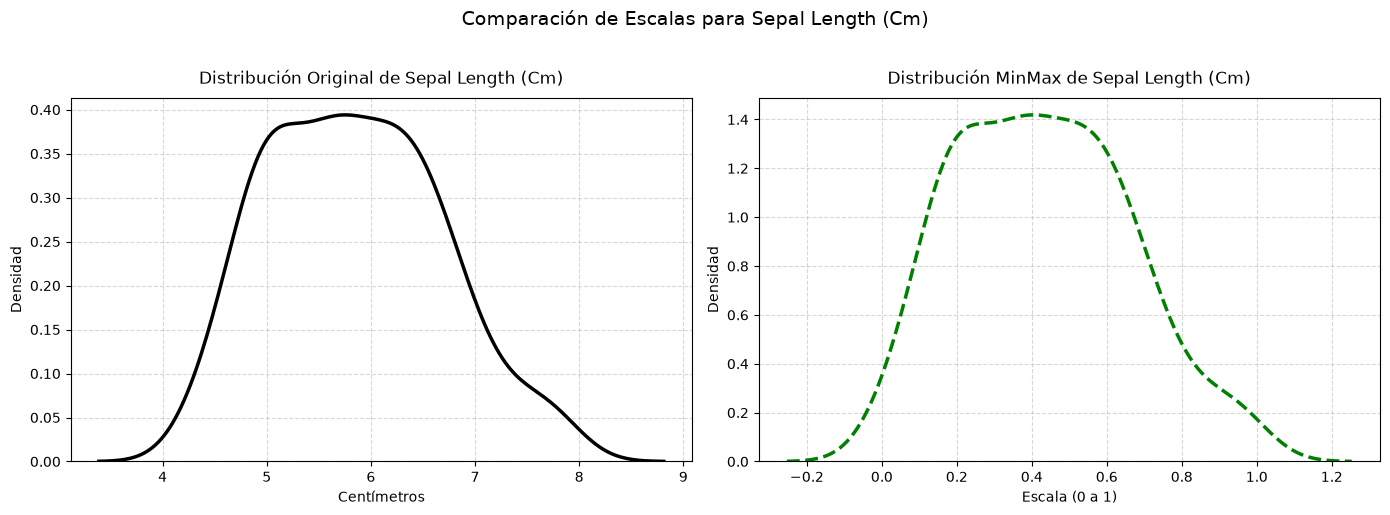

In [20]:
# Definir variable a graficar
col = 'sepal length (cm)'

# Configurar figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Graficar la versión ORIGINAL ---
sns.kdeplot(data[col], ax=ax1, color='black', linewidth=2.5)
ax1.set_title(f'Distribución Original de {col.title()}', fontsize=12, pad=10)
ax1.set_xlabel('Centímetros')
ax1.set_ylabel('Densidad')
ax1.grid(linestyle='--', alpha=0.5)

# --- Graficar la versión MINMAX ---
sns.kdeplot(data_minmax[col], ax=ax2, color='green', linewidth=2.5, linestyle='--')
ax2.set_title(f'Distribución MinMax de {col.title()}', fontsize=12, pad=10)
ax2.set_xlabel('Escala (0 a 1)')
ax2.set_ylabel('Densidad')
ax2.grid(linestyle='--', alpha=0.5)

plt.suptitle(f'Comparación de Escalas para {col.title()}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 3. Crea una gráfica de dispersión entre 'sepal length (cm)' y 'sepal width (cm)' con los datos escalados por StandardScaler.

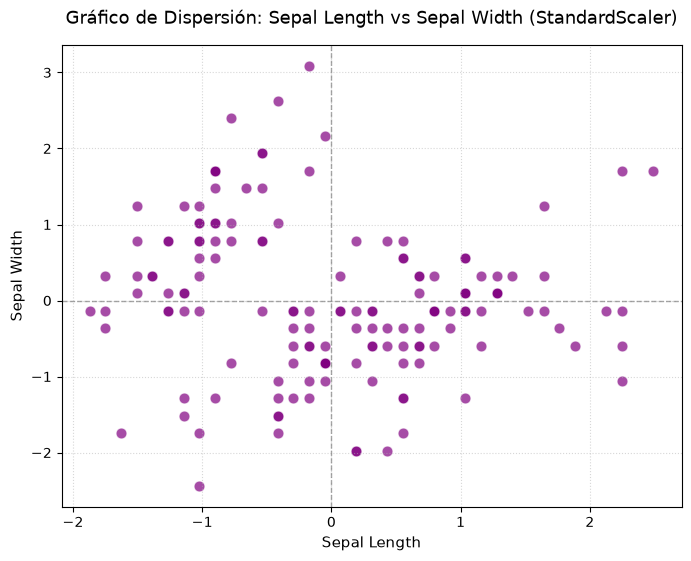

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el tamaño de la figura
plt.figure(figsize=(8, 6))

# 2. Crear el gráfico de dispersión con los datos de StandardScaler
sns.scatterplot(
    data=data_standard, 
    x='sepal length (cm)', 
    y='sepal width (cm)', 
    color='purple', 
    alpha=0.7, 
    s=60
)

# 3. Dibujar líneas de referencia en 0 (opcional, ayuda a ver el centrado del escalado)
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# 4. Personalizar títulos y etiquetas
plt.title('Gráfico de Dispersión: Sepal Length vs Sepal Width (StandardScaler)', fontsize=13, pad=15)
plt.xlabel('Sepal Length', fontsize=11)
plt.ylabel('Sepal Width', fontsize=11)
plt.grid(linestyle=':', alpha=0.5)

# 5. Mostrar la gráfica
plt.show()


### 4. ¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?

Para el dataset Iris, considero que ambas técnicas pueden ser válidas, pero la elección de la más adecuada podría depender directamente del algoritmo de Machine Learning que se vaya a aplicar posteriormente.

- **MinMaxScaler**:
Este método de escalado puede ser una buena opción para este conjunto de datos por las siguientes razones:
    - Rango homogéneo y acotado: Transforma todas las dimensiones de los pétalos y sépalos al rango estricto de 0 a 1. Esto es ideal si planeamos usar algoritmos basados en distancias como KNN o K-Means Clustering, ya que ninguna variable dominará sobre otra debido a su escala original.
    - Ausencia de valores atípicos  extremos: El dataset Iris es un conjunto de datos muy limpio, controlado y biológico, donde las dimensiones de las flores no presentan valores extremoos o "ruido" extremo. Dado que `MinMaxScaler` es sensible a los outliers, al no haberlos aquí, funciona a la perfección.
    - Conserva el límite físico: Las medidas de las plantas no pueden ser negativas. `MinMaxScaler` mantiene los datos en un rango estrictamente positivo [0, 1], lo cual es intuitivo para magnitudes físicas como centímetros.

- **StandardScaler**:
Este método de escalado podría ser una opción óptima si el objetivo es preparar los datos para algoritmos más avanzados:
    - Distribución cercana a la normal: Características como el largo y ancho del sépalo muestran distribuciones acampanadas (unimodales). `StandardScaler` aprovecha esto al centrar la media en 0 y fijar la varianza en 1.
    - Compatibilidad con modelos potentes: Es el escalado requerido si después se va a aplicar PCA para reducir dimensiones, o si se van a entrenar modelos de Regresión Logística, SVM o Redes Neuronales, los cuales convergen mucho más rápido cuando los datos están estandarizados.

Entonces, si el problema se enfoca en clasificación simple por distancias (como KNN) o agrupamiento, `MinMaxScaler` podría ser el mas adecuado. Si el problema busca realizar reducción de dimensiones (PCA) o modelos lineales y probabilísticos, `StandardScaler` podría ser la opción estándar debido a las propiedades estadísticas que le da a la distribución de las variables.
